# Complex Structured Data

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Recognize three structured data types common in chemical engineering — molecular graphs,
  time series, and geospatial data — and the specialized tools used to access each.
- Build and visualize a molecular graph from a public chemistry API.
- Apply a data-historian compression algorithm (the swinging-door method) to a plant signal.
- Read and plot a geospatial dataset with a GIS library.
- Appreciate how AI assistants lower the barrier to working with specialized data formats.
:::

Most of the data in this course has fit comfortably into a table: rows of samples,
columns of features. But a great deal of chemical-engineering data is *structured* in
ways a flat table cannot capture — a molecule is a network of bonded atoms, a sensor
stream is a sequence ordered in time, a pollution map is a collection of shapes on the
Earth's surface. Each of these data types comes with its own file formats, its own
mathematics, and — importantly — its own **specialized access tools**: cheminformatics
APIs for molecules, *data historians* for industrial time series, and *geographic
information systems* (GIS) for spatial data.

Historically, working with any one of these meant climbing a steep learning curve: a
new library, an unfamiliar data model, hours of reading documentation before producing a
single plot. That is exactly where AI assistants change the economics. **Nearly every code
block in this chapter was written by an AI assistant — that is the point.** (The one
exception is the swinging-door algorithm in the time-series example, a standard method
carried over from the Time Series Basics module; there the assistant writes only the code
that applies it.) Spinning up working code to pull a molecular graph, compress a sensor
stream, or draw a watershed map used to be a small project each; now it is a few minutes of
prompting and verifying. As in the previous chapter, the assistant writes the code and we
check that it works — the goal here is not to teach any of these domains in depth, but to
introduce the ideas and show, with worked examples, what is now within easy reach.

A useful way to think about the three examples that follow is in terms of *shape*. A flat
table assumes every record is independent and described by the same fixed set of columns.
The data in this chapter breaks that assumption in three different ways: a molecular graph
has a connectivity structure with no natural column layout, a time series has an ordering
that carries meaning, and geospatial data has a position in space that governs how records
relate to one another. Each broken assumption is why a specialized tool exists, and why
the code to handle it has traditionally been the kind of thing you copied from a colleague
or pieced together over an afternoon.

## Molecular Graphs

A **graph** is just a set of *nodes* connected by *edges*. A molecule is the most natural
chemical example: atoms are nodes, bonds are edges. PubChem (which we met in the previous
chapters) stores exactly this connectivity, so we can ask an assistant to fetch a
compound's atoms and bonds and assemble them into a graph object using `networkx`.

PubChem's record for a compound holds more than a name and a molecular weight: it includes
a full list of atoms, each tagged with its element, and a list of bonds, each joining two
atoms with a bond order. That is precisely the information needed to reconstruct the
molecule's structure — the same thing a chemist would sketch on a whiteboard. The catch is
that it arrives as deeply nested JSON, with the atoms and bonds stored in parallel arrays
and referenced by integer identifiers: perfectly readable by a machine, tedious for a
human to untangle. Converting it into an object you can compute on or draw is exactly the
translation step that an assistant handles well.

> *Prompt: "Using the PubChem PUG REST API, write a function that fetches a compound's
> atoms and bonds by name and returns a networkx graph with each atom labeled by element.
> Then draw the graph for caffeine, coloring atoms by element."*

In [1]:
%matplotlib inline
import requests
import networkx as nx
from api_cache import safe_get   # requests.get with a cached fallback; see Topic 4.2
import matplotlib.pyplot as plt

# Atomic numbers -> symbols (enough for common organic elements)
SYMBOLS = ["", "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
           "Na", "Mg", "Al", "Si", "P", "S", "Cl"]
ELEMENT_COLORS = {"H": "#dddddd", "C": "#404040", "N": "#3050f8",
                  "O": "#ff2010", "S": "#ffff30", "P": "#ff8000"}

def molecular_graph(name):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/JSON"
    record = safe_get(url).json()["PC_Compounds"][0]
    atoms, bonds = record["atoms"], record["bonds"]
    G = nx.Graph()
    for aid, z in zip(atoms["aid"], atoms["element"]):
        G.add_node(aid, element=SYMBOLS[z])
    for a1, a2 in zip(bonds["aid1"], bonds["aid2"]):
        G.add_edge(a1, a2)
    return G

G = molecular_graph("caffeine")
print(f"{G.number_of_nodes()} atoms, {G.number_of_edges()} bonds")

24 atoms, 25 bonds


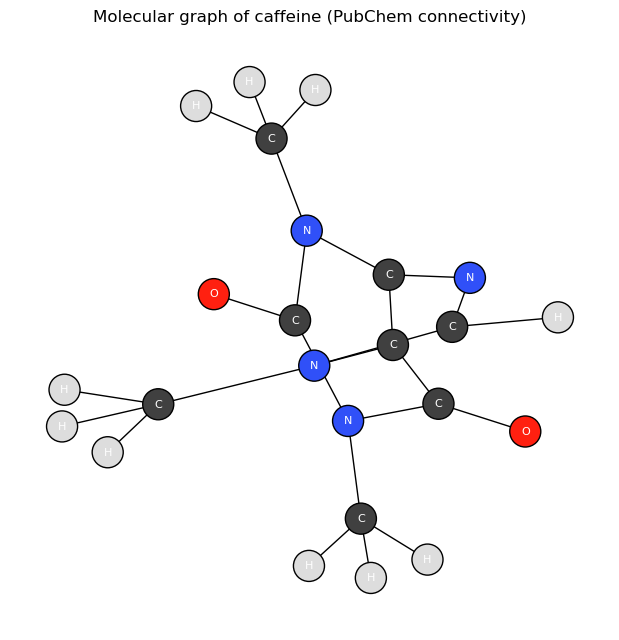

In [2]:
elements = nx.get_node_attributes(G, "element")
colors = [ELEMENT_COLORS.get(elements[n], "#cc66cc") for n in G.nodes]
pos = nx.spring_layout(G, seed=4)

plt.figure(figsize=(6, 6))
nx.draw(G, pos, node_color=colors, labels=elements, with_labels=True,
        node_size=500, font_color="white", font_size=8, edgecolors="black")
plt.title("Molecular graph of caffeine (PubChem connectivity)")
plt.show()

In a few lines we have turned an API response into a labeled graph and a picture of the
molecule's connectivity. The payoff is bigger than chemistry, though: **graphs represent
relationships of all kinds in science and engineering.** Reaction networks, process
flowsheets, the dependency structure among process variables, and state-transition
diagrams are all graphs, and the same `networkx` toolkit applies to every one of them.
Specialized access for graph data shows up as cheminformatics APIs and libraries (PubChem,
RDKit) and, more generally, graph databases.

Representing data as a graph is more than a convenience for drawing pictures: the structure
itself carries information. Which atoms are bonded, how many edges separate two nodes,
whether the graph contains rings or long chains — these are the features that determine
chemical behavior, and they are invisible in a flat list of atoms. An entire family of
machine-learning methods, *graph neural networks*, operates directly on this connectivity
to predict properties such as solubility or reactivity, and the very same models apply to
any networked system, from power grids to metabolic pathways.

Because the molecule now *is* a graph object, those structural questions become one-line
computations. `networkx` can count the independent rings in a molecule directly (via
`cycle_basis` — for a connected graph the count is simply $E - N + 1$, the number of bonds
beyond what a ring-free tree would need), and the node degrees tell us which atoms are the
connective hubs:

> *Prompt: "Using the molecular_graph function, compare caffeine and aspirin: count each
> molecule's rings and their sizes, and report the most highly connected atoms."*

In [3]:
G_asp = molecular_graph("aspirin")

for name, g in [("caffeine", G), ("aspirin", G_asp)]:
    rings = nx.cycle_basis(g)
    ring_sizes = sorted(len(r) for r in rings)
    els = nx.get_node_attributes(g, "element")
    hubs = [(els[a], d) for a, d in sorted(g.degree, key=lambda kv: -kv[1])[:3]]
    print(f"{name}: {g.number_of_nodes()} atoms, {g.number_of_edges()} bonds, "
          f"{len(rings)} rings (sizes {ring_sizes}), top-degree atoms {hubs}")

caffeine: 24 atoms, 25 bonds, 2 rings (sizes [5, 6]), top-degree atoms [('C', 4), ('C', 4), ('C', 4)]
aspirin: 21 atoms, 21 bonds, 1 rings (sizes [6]), top-degree atoms [('C', 4), ('C', 3), ('C', 3)]


Both ring counts check out against the known structures: caffeine's fused bicyclic core is
a five-membered imidazole sharing an edge with a six-membered pyrimidinedione ring (2
rings), while aspirin contains a single six-membered benzene ring. (The top-degree atoms
in both molecules are the methyl carbons — the PubChem graph includes hydrogens.) This is
the pattern to remember:
once connectivity data is in a graph object, structural questions — ring counts, chain
lengths, which nodes hold the network together — stop being parsing problems and become
library calls.

The reason this kind of work used to be slow is that every graph data source stores its
connectivity in its own idiosyncratic format — PubChem's atom/bond record looks nothing
like a social-network export or a flowsheet file. Translating each one into a common graph
object meant reading documentation and writing fiddly parsing code by hand. An assistant
that already knows these schemas collapses that effort to a single prompt, which is what
makes casually exploring a new graph data source realistic.

:::{exercise}
:label: ex-dm-graph-network

Work with an LLM of your choice to build the molecular graph for a different molecule
(for example ibuprofen or glucose), then ask it to compute a graph property *not* shown
above — the graph diameter (the longest shortest-path between any two atoms), or the
number of terminal (degree-1) heavy atoms — and check the result against the molecule's
known structure.
:::

## Time Series and Data Historians

A **time series** is a sequence of values ordered in time, and a running chemical plant
produces it in vast quantities — thousands of sensors sampled continuously. Such data is
stored in **data historians**, which compress each stream as it arrives. The reasoning
behind historians and the **swinging-door compression algorithm** are covered in detail in
[Time Series Basics](../6-advanced_topics/Topic6.1-Time_Series_Basics); here we simply
reuse that algorithm and ask the assistant to apply it to our dataset.

What makes a time series different from an ordinary table is that the row order *is* data:
shuffle the rows and you destroy the trends, cycles, and correlations that the whole
analysis depends on. That ordering also means the data never stops arriving, which is why
the tooling around it is built for streams rather than fixed files — and why storage and
compression become first-class concerns rather than afterthoughts.

The swinging-door function below is the standard algorithm carried over from that module
(reproduced so this notebook runs on its own) — not something the assistant invented:

In [4]:
import numpy as np

def swinging_door(t, y, delta):
    """Swinging-door (SDT) compression — see Time Series Basics for the derivation."""
    keep = [0]
    t0, y0 = t[0], y[0]
    s_max, s_min = -np.inf, np.inf
    for i in range(1, len(y)):
        dt = t[i] - t0
        s_min = min(s_min, (y[i] + delta - y0) / dt)
        s_max = max(s_max, (y[i] - delta - y0) / dt)
        if s_max > s_min:
            keep.append(i - 1)
            t0, y0 = t[i - 1], y[i - 1]
            dt = t[i] - t0
            s_min = (y[i] + delta - y0) / dt
            s_max = (y[i] - delta - y0) / dt
    keep.append(len(y) - 1)
    return np.array(sorted(set(keep)))

We then asked the assistant only to write the code that *applies* it to a process
variable from the Dow dataset and reports the compression achieved:

> *Prompt: "Load the reflux-flow column of the Dow dataset, compress it with the
> swinging_door function at a tolerance of 0.1 standard deviations, plot the original
> against the retained points, and print the compression ratio."*

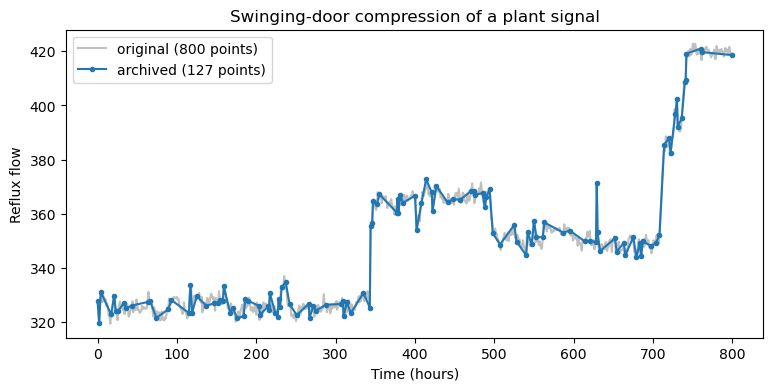

Compression ratio: 6.3x


In [5]:
import pandas as pd

dow = pd.read_excel("data/impurity_dataset-training.xlsx")
signal = dow["x1:Primary Column Reflux Flow"].to_numpy()[:800]
t = np.arange(len(signal), dtype=float)

kept = swinging_door(t, signal, delta=0.1 * np.std(signal))

plt.figure(figsize=(9, 4))
plt.plot(t, signal, color="0.75", label=f"original ({len(signal)} points)")
plt.plot(t[kept], signal[kept], "o-", ms=3, label=f"archived ({len(kept)} points)")
plt.xlabel("Time (hours)"); plt.ylabel("Reflux flow")
plt.legend(); plt.title("Swinging-door compression of a plant signal")
plt.show()

print(f"Compression ratio: {len(signal) / len(kept):.1f}x")

Even on a single variable the saving is substantial; multiplied across the tens of
thousands of tags in a real plant, this kind of compression is what makes storing years of
process history feasible at all.

The choices a historian makes are not neutral, and this matters for any analysis you do
later. The sampling rate sets the highest-frequency behavior you can ever observe, and the
compression tolerance sets how much fine structure survives — a transient that lasted a few
seconds may simply not exist in the archived record. When you pull data from a historian
months after the fact, you are analyzing what it chose to keep, not the raw physical signal,
so understanding the storage layer is part of understanding the data. The swinging-door
method endures precisely because it is cheap enough to run in real time on a live stream
while still giving a hard guarantee that the stored signal never strays beyond the chosen
tolerance.

In industry you will rarely implement this layer yourself — you will pull data *out* of an
existing historian. The commercial products dominate operating plants because they speak
industrial protocols (OPC UA, DCS-native connections) and implement compression natively,
while general-purpose open-source time-series databases are increasingly common for lab
equipment, pilot plants, and IoT-style projects. Options worth knowing:

| Software | Category | Strengths | Weaknesses |
|---|---|---|---|
| AVEVA PI System (formerly OSIsoft PI) | Commercial historian | De-facto industry standard; huge installed base; rich tooling and asset framework; mature Python/Excel access | Expensive licensing; proprietary stack; can be heavyweight for small projects |
| AspenTech InfoPlus.21 | Commercial historian | Deep integration with Aspen process simulation and APC tools; strong in chemicals/refining | Costly; steeper administration; smaller community than PI |
| Honeywell Uniformance PHD | Commercial historian | Tight coupling to Honeywell DCS environments; proven at refinery scale | Mostly encountered in Honeywell shops; limited ecosystem outside them |
| Ignition (+ Canary/SQL historian) | Commercial SCADA + historian | Affordable, unlimited-tag licensing; modern web tooling; Python (Jython) scripting built in | Historian features thinner than dedicated products; analytics mostly DIY |
| InfluxDB | Open-source time-series database | Free to start; purpose-built for high-ingest time series; good dashboards (Grafana) | Not a process historian: no native OPC connectivity or swinging-door-style compression; OT integration is DIY |
| TimescaleDB | Open-source (PostgreSQL extension) | Full SQL; joins time series with relational plant data; compression built in | Same OT-integration gap as InfluxDB; requires database administration comfort |

The names change, but the interface pattern does not: every historian exposes tag-based
queries over a time range, and the compression caveats above apply to all of them.

:::{exercise}
:label: ex-dm-historian-tol

Work with an LLM of your choice to apply the swinging-door function to a *different*
process variable and at two or three different tolerances, and report how the compression
ratio changes. (The trade-off against reconstruction error is explored in the Time Series
Basics exercises.)
:::

## Geospatial Data

**Geospatial data** describes things with a location on the Earth's surface — points,
lines, and polygons tagged with coordinates. It is central to environmental engineering:
watershed boundaries, emissions inventories, contamination plumes, and facility siting are
all spatial questions. The data lives in specialized formats (GeoJSON, shapefiles) tied to
*coordinate reference systems*, and is handled by **geographic information systems** (GIS)
— desktop tools like ArcGIS and QGIS, web services following OGC/ArcGIS REST standards,
and, in Python, the `geopandas` library.

Following the responsible-data practice from the previous chapter, we downloaded the
watershed boundaries for the metro-Atlanta area once from the USGS Watershed Boundary
Dataset and saved them as a GeoJSON file, so this example is reproducible without hitting a
live GIS server on every build. The one-time download is shown below, commented out so the
book does not contact the live GIS server each time it is built:

In [6]:
# One-time download that produced data/atl_watersheds.geojson (commented out).
#
# import requests, json
#
# # USGS Watershed Boundary Dataset, "Watershed" layer (HUC10), via the ArcGIS REST API.
# WBD = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/5/query"
# bbox = {"xmin": -84.55, "ymin": 33.65, "xmax": -84.25, "ymax": 33.90,
#         "spatialReference": {"wkid": 4326}}
# params = {
#     "where": "1=1",
#     "geometry": json.dumps(bbox),
#     "geometryType": "esriGeometryEnvelope",
#     "inSR": 4326, "outSR": 4326,
#     "spatialRel": "esriSpatialRelIntersects",
#     "outFields": "name,huc10,areasqkm,states",
#     "returnGeometry": "true",
#     "f": "geojson",
# }
# r = requests.get(WBD, params=params); r.raise_for_status()
# with open("data/atl_watersheds.geojson", "w") as fh:
#     fh.write(r.text)

> *Prompt: "Using geopandas, read the cached metro-Atlanta watershed GeoJSON and plot the
> watersheds colored by name, with a legend."*

                          name  areasqkm
Sope Creek-Chattahoochee River    315.72
               Peachtree Creek    338.49
Utoy Creek-Chattahoochee River    305.91
 Dog River-Chattahoochee River   1008.94
     Morning Creek-Flint River    791.74
             Upper South River    644.06


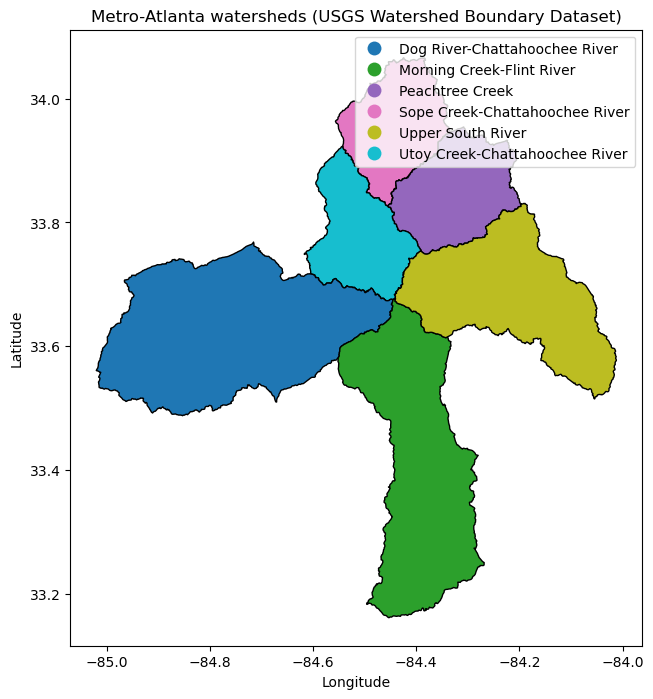

In [7]:
import geopandas as gpd

watersheds = gpd.read_file("data/atl_watersheds.geojson")
print(watersheds[["name", "areasqkm"]].to_string(index=False))

ax = watersheds.plot(column="name", figsize=(8, 8), edgecolor="black",
                     legend=True, cmap="tab10")
ax.set_title("Metro-Atlanta watersheds (USGS Watershed Boundary Dataset)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()

These are the sub-watersheds draining the Atlanta region — Peachtree Creek, Utoy Creek,
and the Sope Creek and Dog River stretches of the Chattahoochee, plus the headwaters of the
Flint and South Rivers. With the geometries loaded as a `geopandas` object, the full
toolkit of spatial analysis is available: computing areas, finding which watershed contains
a given point, overlaying monitoring stations or discharge points, and so on — none of
which would be quick to write from scratch without the specialized library.

Areas are a one-line example — with one wrinkle. The geometries are stored in
latitude/longitude coordinates, where "area" would come out in meaningless square degrees,
so the layer must first be reprojected onto an equal-area coordinate system measured in
meters:

> *Prompt: "Compute the area of each watershed in km² from the geometries and compare to
> the dataset's areasqkm attribute."*

In [8]:
ws_albers = watersheds.to_crs(epsg=5070)   # NAD83 / Conus Albers (equal-area, meters)
computed = ws_albers.geometry.area / 1e6   # m² → km²

comparison = watersheds[["name", "areasqkm"]].assign(computed_sqkm=computed.round(1))
print(comparison.to_string(index=False))

                          name  areasqkm  computed_sqkm
Sope Creek-Chattahoochee River    315.72          315.7
               Peachtree Creek    338.49          338.5
Utoy Creek-Chattahoochee River    305.91          305.9
 Dog River-Chattahoochee River   1008.94         1008.9
     Morning Creek-Flint River    791.74          791.7
             Upper South River    644.06          644.1


The computed values agree with the `areasqkm` attribute reported by the USGS — a
reassuring check that the geometries survived the download-and-cache round trip intact,
and a reminder that a spatial dataset's attributes can be recomputed from its geometry
whenever provenance is in doubt.

Two ideas make geospatial data a discipline of its own. The first is the *coordinate
reference system*: because the Earth is curved and maps are flat, every dataset specifies
how its coordinates project onto the globe, and silently mixing two systems lands features
in the wrong place — a common and costly mistake. The second is the split between *vector*
data (discrete points, lines, and polygons, like our watershed boundaries) and *raster*
data (values on a regular grid, like a satellite image or a digital elevation model). GIS
tools handle both, along with the operations that connect them.

For an environmental engineer those operations are the whole point: clipping a pollutant
concentration raster to a watershed polygon, measuring the land area that drains to a
sampling station, or finding every permitted discharge within a buffer distance of a
stream. Each is essentially a one-line call in `geopandas` and a substantial undertaking
without it — which, once again, is why being able to generate the surrounding code on
demand changes what is worth attempting.

:::{exercise}
:label: ex-dm-gis-overlay

Work with an LLM of your choice to overlay a single point on the watershed map — for
example the Georgia Tech campus at (33.776, −84.398) — and determine which watershed it
falls within. Alternatively, have it compute each watershed's boundary length (perimeter)
in km, being careful about the coordinate reference system as shown above.
:::

## Summary

- Chemical-engineering data is often **structured** in ways a flat table cannot hold:
  molecular graphs, time series, and geospatial data are three common examples.
- Each type has **specialized access tooling** — cheminformatics APIs (PubChem, RDKit),
  data historians (PI System, InfluxDB), and GIS systems (`geopandas`, ArcGIS) — that once
  represented a steep barrier to entry.
- AI assistants dramatically lower that barrier: in a few prompts we built a molecular
  graph, compressed a plant signal with the swinging-door algorithm, and mapped metro-Atlanta
  watersheds.
- The verification habit from the previous chapter still applies — generated code for an
  unfamiliar data type should always be checked by running it and sanity-checking the
  result.

None of these three examples is something you would have been expected to produce quickly a
few years ago without prior experience in the specific domain. The broader lesson is not
about molecules, sensors, or maps in particular, but about reach: when the cost of writing
the first working script for an unfamiliar data type drops to a single prompt, far more of
the data around a problem becomes fair game for analysis.

## Additional Reading

- [NetworkX documentation](https://networkx.org/) — graphs in Python, far beyond molecules.
- [PubChem PUG REST documentation](https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest) — the atom/bond records used above.
- [AVEVA PI System](https://www.aveva.com/en/products/pi-system/) and [InfluxDB](https://www.influxdata.com/) — industrial and open-source data historians; the swinging-door algorithm originates in this setting.
- [GeoPandas documentation](https://geopandas.org/) and the [USGS Watershed Boundary Dataset](https://www.usgs.gov/national-hydrography/watershed-boundary-dataset) — the GIS library and data source used here.